# PAMAP - Comparación K-Fold vs LOSO CV

Se comparan los siguientes métodos:

- Linear interpolation
- Remover las filas donde haya faltantes

Actividades:
 - 1	lying
 - 2	sitting
 - 3	standing
 - 4	walking
 - 5	running
 - 6	cycling
 - 7	Nordic walking
 - 9	watching TV
 - 10	computer work
 - 11	car driving
 - 12	ascending stairs
 - 13	descending stairs
 - 16	vacuum cleaning
 - 17	ironing
 - 18	folding laundry
 - 19	house cleaning
 - 20	playing soccer
 - 24	rope jumping
 - 0	other (transient activities)

Sujetos: 9 sujetos

Frecuencia de muestreo:
- **IMU**: 100Hz
- **HR**: 9Hz

# 1.    Cargar datos

Cargamos las librerías

In [8]:
import pandas as pd
import os

pd.set_option("display.float_format", "{:.3f}".format)

Definimos el cargador de datos

In [10]:
from abc import ABC, abstractmethod


# DEFINIMOS LA INTERFAZ DEL CARGADOR DE DATOS ---------------------------------------------------------------------------------------------
class AbstractDataLoader(ABC):
    def __init__(self, src_path:str, keys:list, file_extension:str, delimiter:str):
        self.src_path = src_path
        self.keys = keys
        self.file_extension = file_extension
        self.delimiter = delimiter     
        
    @abstractmethod
    def load_data(self):
        pass

    @abstractmethod
    def _is_valid_extension(self, file):
        pass

# CREAMOS EL CARGADOR DE DATOS PARA PAMAP2 ---------------------------------------------------------------------------------------------
class DataLoader(AbstractDataLoader):
    def __init__(self, src_path:str, keys:list, file_extension:str, delimiter:str):
        super().__init__(src_path, keys, file_extension, delimiter)
        
    
    def load_data(self):
        dataframes = []
        for file in os.listdir(self.src_path):
            if self._is_valid_extension(file):  
                df = pd.read_csv(os.path.join(self.src_path, file), delimiter=self.delimiter, names=self.keys)
                df['subject_id'] = self._get_subject_id(file)
                dataframes.append(df)
        final_df = pd.concat(dataframes, ignore_index=True)
        return final_df

                
    def _is_valid_extension(self, file):
        return file.endswith(self.file_extension)

    def _get_subject_id(self, file):
        return file.split('.')[0]

Definomos las columnas de los sensores y realizamos la carga

In [12]:
src = "dataset/PAMAP2/PAMAP2_Dataset/Protocol/"
keys = [
    "timestamp",
    "activityID",
    "heart_rate_bpm",
    # IMU Hand (columns 4–20)
    "IMU_Hand_temperature",
    "IMU_Hand_acceleration_16g_x",
    "IMU_Hand_acceleration_16g_y",
    "IMU_Hand_acceleration_16g_z",
    "IMU_Hand_acceleration_6g_x",
    "IMU_Hand_acceleration_6g_y",
    "IMU_Hand_acceleration_6g_z",
    "IMU_Hand_gyroscope_x",
    "IMU_Hand_gyroscope_y",
    "IMU_Hand_gyroscope_z",
    "IMU_Hand_magnetometer_x",
    "IMU_Hand_magnetometer_y",
    "IMU_Hand_magnetometer_z",
    "IMU_Hand_orientation_1",
    "IMU_Hand_orientation_2",
    "IMU_Hand_orientation_3",
    "IMU_Hand_orientation_4",
    # IMU Chest (columns 21–37)
    "IMU_Chest_temperature",
    "IMU_Chest_acceleration_16g_x",
    "IMU_Chest_acceleration_16g_y",
    "IMU_Chest_acceleration_16g_z",
    "IMU_Chest_acceleration_6g_x",
    "IMU_Chest_acceleration_6g_y",
    "IMU_Chest_acceleration_6g_z",
    "IMU_Chest_gyroscope_x",
    "IMU_Chest_gyroscope_y",
    "IMU_Chest_gyroscope_z",
    "IMU_Chest_magnetometer_x",
    "IMU_Chest_magnetometer_y",
    "IMU_Chest_magnetometer_z",
    "IMU_Chest_orientation_1",
    "IMU_Chest_orientation_2",
    "IMU_Chest_orientation_3",
    "IMU_Chest_orientation_4",
    # IMU Ankle (columns 38–54)
    "IMU_Ankle_temperature",
    "IMU_Ankle_acceleration_16g_x",
    "IMU_Ankle_acceleration_16g_y",
    "IMU_Ankle_acceleration_16g_z",
    "IMU_Ankle_acceleration_6g_x",
    "IMU_Ankle_acceleration_6g_y",
    "IMU_Ankle_acceleration_6g_z",
    "IMU_Ankle_gyroscope_x",
    "IMU_Ankle_gyroscope_y",
    "IMU_Ankle_gyroscope_z",
    "IMU_Ankle_magnetometer_x",
    "IMU_Ankle_magnetometer_y",
    "IMU_Ankle_magnetometer_z",
    "IMU_Ankle_orientation_1",
    "IMU_Ankle_orientation_2",
    "IMU_Ankle_orientation_3",
    "IMU_Ankle_orientation_4"
]

file_extension = '.dat'
delimiter = r'\s+'
data_loader_pamap = DataLoader(src, keys, file_extension, delimiter)
pamap_data = data_loader_pamap.load_data()

pamap_data.shape

(2872533, 55)

In [13]:
pamap_data.dtypes

timestamp                       float64
activityID                        int64
heart_rate_bpm                  float64
IMU_Hand_temperature            float64
IMU_Hand_acceleration_16g_x     float64
IMU_Hand_acceleration_16g_y     float64
IMU_Hand_acceleration_16g_z     float64
IMU_Hand_acceleration_6g_x      float64
IMU_Hand_acceleration_6g_y      float64
IMU_Hand_acceleration_6g_z      float64
IMU_Hand_gyroscope_x            float64
IMU_Hand_gyroscope_y            float64
IMU_Hand_gyroscope_z            float64
IMU_Hand_magnetometer_x         float64
IMU_Hand_magnetometer_y         float64
IMU_Hand_magnetometer_z         float64
IMU_Hand_orientation_1          float64
IMU_Hand_orientation_2          float64
IMU_Hand_orientation_3          float64
IMU_Hand_orientation_4          float64
IMU_Chest_temperature           float64
IMU_Chest_acceleration_16g_x    float64
IMU_Chest_acceleration_16g_y    float64
IMU_Chest_acceleration_16g_z    float64
IMU_Chest_acceleration_6g_x     float64


In [14]:
pamap_data.head()

,timestamp,activityID,heart_rate_bpm,IMU_Hand_temperature,IMU_Hand_acceleration_16g_x,IMU_Hand_acceleration_16g_y,IMU_Hand_acceleration_16g_z,IMU_Hand_acceleration_6g_x,IMU_Hand_acceleration_6g_y,IMU_Hand_acceleration_6g_z,...,IMU_Ankle_gyroscope_y,IMU_Ankle_gyroscope_z,IMU_Ankle_magnetometer_x,IMU_Ankle_magnetometer_y,IMU_Ankle_magnetometer_z,IMU_Ankle_orientation_1,IMU_Ankle_orientation_2,IMU_Ankle_orientation_3,IMU_Ankle_orientation_4,subject_id
0,8.380,0,104.000,30.000,2.372,8.601,3.510,2.440,8.762,3.355,...,0.009,-0.018,-61.189,-38.960,-58.144,1.000,0.000,0.000,0.000,subject101
1,8.390,0,NaN,30.000,2.188,8.566,3.662,2.395,8.551,3.642,...,-0.005,0.000,-59.848,-38.892,-58.525,1.000,0.000,0.000,0.000,subject101
2,8.400,0,NaN,30.000,2.374,8.601,3.549,2.305,8.536,3.733,...,0.000,0.022,-60.736,-39.414,-58.400,1.000,0.000,0.000,0.000,subject101
3,8.410,0,NaN,30.000,2.075,8.529,3.660,2.335,8.536,3.733,...,-0.020,0.011,-60.409,-38.764,-58.396,1.000,0.000,0.000,0.000,subject101
4,8.420,0,NaN,30.000,2.229,8.831,3.700,2.231,8.597,3.763,...,-0.014,-0.003,-61.520,-39.388,-58.269,1.000,0.000,0.000,0.000,subject101


In [15]:
pamap_data.describe()

,timestamp,activityID,heart_rate_bpm,IMU_Hand_temperature,IMU_Hand_acceleration_16g_x,IMU_Hand_acceleration_16g_y,IMU_Hand_acceleration_16g_z,IMU_Hand_acceleration_6g_x,IMU_Hand_acceleration_6g_y,IMU_Hand_acceleration_6g_z,...,IMU_Ankle_gyroscope_x,IMU_Ankle_gyroscope_y,IMU_Ankle_gyroscope_z,IMU_Ankle_magnetometer_x,IMU_Ankle_magnetometer_y,IMU_Ankle_magnetometer_z,IMU_Ankle_orientation_1,IMU_Ankle_orientation_2,IMU_Ankle_orientation_3,IMU_Ankle_orientation_4
count,2872533.000,2872533.000,262268.000,2859392.000,2859392.000,2859392.000,2859392.000,2859392.000,2859392.000,2859392.000,...,2860784.000,2860784.000,2860784.000,2860784.000,2860784.000,2860784.000,2860784.000,2860784.000,2860784.000,2860784.000
mean,1834.354,5.466,109.873,32.653,-4.961,3.588,3.168,-4.889,3.584,3.349,...,0.009,-0.035,0.008,-32.721,1.593,16.890,0.399,0.022,0.309,-0.019
std,1105.689,6.331,25.870,1.844,5.985,6.278,3.844,5.993,6.056,3.841,...,1.074,0.597,1.843,18.879,21.612,20.309,0.303,0.569,0.324,0.473
min,5.640,0.000,57.000,24.750,-145.367,-104.301,-101.452,-61.489,-61.868,-61.935,...,-23.995,-18.127,-14.020,-172.865,-137.908,-109.289,-0.254,-0.957,-0.877,-0.997
25%,893.160,0.000,90.000,31.438,-9.028,1.290,0.969,-8.933,1.285,1.164,...,-0.153,-0.083,-0.308,-42.895,-11.485,3.289,0.156,-0.584,0.011,-0.505
50%,1790.830,3.000,108.000,33.125,-5.788,3.571,2.958,-5.738,3.613,3.133,...,0.004,-0.004,-0.002,-33.900,1.363,18.091,0.320,0.000,0.304,0.000
75%,2710.570,7.000,125.000,34.000,-0.783,6.603,6.003,-0.725,6.602,6.258,...,0.095,0.083,0.063,-19.059,17.331,30.878,0.579,0.628,0.602,0.463
max,4475.630,24.000,202.000,35.500,62.860,155.699,157.760,52.821,62.260,61.945,...,17.420,13.588,16.529,97.525,123.306,146.900,1.000,0.960,0.992,0.996


In [16]:
pamap_data.isnull().sum()

timestamp                             0
activityID                            0
heart_rate_bpm                  2610265
IMU_Hand_temperature              13141
IMU_Hand_acceleration_16g_x       13141
IMU_Hand_acceleration_16g_y       13141
IMU_Hand_acceleration_16g_z       13141
IMU_Hand_acceleration_6g_x        13141
IMU_Hand_acceleration_6g_y        13141
IMU_Hand_acceleration_6g_z        13141
IMU_Hand_gyroscope_x              13141
IMU_Hand_gyroscope_y              13141
IMU_Hand_gyroscope_z              13141
IMU_Hand_magnetometer_x           13141
IMU_Hand_magnetometer_y           13141
IMU_Hand_magnetometer_z           13141
IMU_Hand_orientation_1            13141
IMU_Hand_orientation_2            13141
IMU_Hand_orientation_3            13141
IMU_Hand_orientation_4            13141
IMU_Chest_temperature              3563
IMU_Chest_acceleration_16g_x       3563
IMU_Chest_acceleration_16g_y       3563
IMU_Chest_acceleration_16g_z       3563
IMU_Chest_acceleration_6g_x        3563


# 2. Tratamiento de datos irrelevantes

Eliminamos:
- Sujeto 9: no realiza todas las actividaes
- Label 0: representa actividades de transición

## 2.1. Eliminar el sujeto 9

Antes:
- 9 valores únicos que se corresponden con nuestros 9 sujetos
- queremos eliminar el sujeto 9 bajo el label "subject109"

In [21]:
pamap_data.subject_id.describe()

count        2872533
unique             9
top       subject102
freq          447000
Name: subject_id, dtype: object

In [22]:
pamap_data['subject_id'].unique()

array(['subject101', 'subject102', 'subject103', 'subject104',
       'subject105', 'subject106', 'subject107', 'subject108',
       'subject109'], dtype=object)

Eliminamos al sujeto 9

In [24]:
pamap_data = pamap_data[pamap_data['subject_id'] != "subject109" ]

Después:
- ahora solo hay 8 únicos
- el "subject109" ya no está

In [26]:
pamap_data.subject_id.describe()

count        2864056
unique             8
top       subject102
freq          447000
Name: subject_id, dtype: object

In [27]:
pamap_data['subject_id'].unique()

array(['subject101', 'subject102', 'subject103', 'subject104',
       'subject105', 'subject106', 'subject107', 'subject108'],
      dtype=object)

## 2.2. Eliminar la actividad de transición

Antes: 
- 13 actividades en total
- label 0 que representa transición

In [30]:
no_activities = len(pamap_data.activityID.unique())
labels_list = pamap_data.activityID.unique()

print(f"Number of unique activities: {no_activities}\n Activity labels: {labels_list}")

Number of unique activities: 13
 Activity labels: [ 0  1  2  3 17 16 12 13  4  7  6  5 24]


Eliminamos la actividad 0

In [32]:
pamap_data = pamap_data[pamap_data['activityID'] != 0]

Después:
- 12 actividades
- ya no hay 0

In [34]:
no_activities_post = len(pamap_data.activityID.unique())
labels_list_post = pamap_data.activityID.unique()

print(f"Number of unique activities: {no_activities_post}\n Activity labels: {labels_list_post}")

Number of unique activities: 12
 Activity labels: [ 1  2  3 17 16 12 13  4  7  6  5 24]


## 2.3. Filtrar columnas irrelevantes

Filtramos las columnas irrelevantes:
- 6g
- Orientation
- Heart Rate
- Temperature

In [37]:
irrelevant_columns = [
    # 6g
    'IMU_Hand_acceleration_6g_x',
    'IMU_Hand_acceleration_6g_y',
    'IMU_Hand_acceleration_6g_z',
    'IMU_Chest_acceleration_6g_x',
    'IMU_Chest_acceleration_6g_y',
    'IMU_Chest_acceleration_6g_z',
    'IMU_Ankle_acceleration_6g_x',
    'IMU_Ankle_acceleration_6g_y',
    'IMU_Ankle_acceleration_6g_z',
    'IMU_Ankle_acceleration_6g_x',
    'IMU_Ankle_acceleration_6g_y',
    'IMU_Ankle_acceleration_6g_z',
    # orientation
    'IMU_Ankle_orientation_1',
    'IMU_Ankle_orientation_2',
    'IMU_Ankle_orientation_3',
    'IMU_Ankle_orientation_4',
    'IMU_Hand_orientation_1',
    'IMU_Hand_orientation_2',
    'IMU_Hand_orientation_3',
    'IMU_Hand_orientation_4',
    'IMU_Chest_orientation_1',
    'IMU_Chest_orientation_2',
    'IMU_Chest_orientation_3',
    'IMU_Chest_orientation_4',
    # heart rate
    'heart_rate_bpm', 
    # temperature
    'IMU_Hand_temperature',
    'IMU_Chest_temperature',
    'IMU_Ankle_temperature'
]

pamap_data_filtered = pamap_data.drop(columns=irrelevant_columns, errors='ignore')
pamap_data_filtered.isnull().sum()

timestamp                           0
activityID                          0
IMU_Hand_acceleration_16g_x     11122
IMU_Hand_acceleration_16g_y     11122
IMU_Hand_acceleration_16g_z     11122
IMU_Hand_gyroscope_x            11122
IMU_Hand_gyroscope_y            11122
IMU_Hand_gyroscope_z            11122
IMU_Hand_magnetometer_x         11122
IMU_Hand_magnetometer_y         11122
IMU_Hand_magnetometer_z         11122
IMU_Chest_acceleration_16g_x     2420
IMU_Chest_acceleration_16g_y     2420
IMU_Chest_acceleration_16g_z     2420
IMU_Chest_gyroscope_x            2420
IMU_Chest_gyroscope_y            2420
IMU_Chest_gyroscope_z            2420
IMU_Chest_magnetometer_x         2420
IMU_Chest_magnetometer_y         2420
IMU_Chest_magnetometer_z         2420
IMU_Ankle_acceleration_16g_x     8504
IMU_Ankle_acceleration_16g_y     8504
IMU_Ankle_acceleration_16g_z     8504
IMU_Ankle_gyroscope_x            8504
IMU_Ankle_gyroscope_y            8504
IMU_Ankle_gyroscope_z            8504
IMU_Ankle_ma

# 3. Tratamiento de valores faltantes

## 3.1. Análisis de valores faltantes

En total hay 198,414 datos faltantes

In [41]:
pamap_data_filtered.isna().sum().sum()

198414

Vemos que el patrón es la parte del cuerpo en la que el sensor está puesto

In [43]:
pamap_data_filtered.isnull().sum()

timestamp                           0
activityID                          0
IMU_Hand_acceleration_16g_x     11122
IMU_Hand_acceleration_16g_y     11122
IMU_Hand_acceleration_16g_z     11122
IMU_Hand_gyroscope_x            11122
IMU_Hand_gyroscope_y            11122
IMU_Hand_gyroscope_z            11122
IMU_Hand_magnetometer_x         11122
IMU_Hand_magnetometer_y         11122
IMU_Hand_magnetometer_z         11122
IMU_Chest_acceleration_16g_x     2420
IMU_Chest_acceleration_16g_y     2420
IMU_Chest_acceleration_16g_z     2420
IMU_Chest_gyroscope_x            2420
IMU_Chest_gyroscope_y            2420
IMU_Chest_gyroscope_z            2420
IMU_Chest_magnetometer_x         2420
IMU_Chest_magnetometer_y         2420
IMU_Chest_magnetometer_z         2420
IMU_Ankle_acceleration_16g_x     8504
IMU_Ankle_acceleration_16g_y     8504
IMU_Ankle_acceleration_16g_z     8504
IMU_Ankle_gyroscope_x            8504
IMU_Ankle_gyroscope_y            8504
IMU_Ankle_gyroscope_z            8504
IMU_Ankle_ma

Los faltantes por parte del cuerpo son:

In [45]:
# Definir las partes del cuerpo
body_parts = ['Hand', 'Chest', 'Ankle']

# Calcular cuántas filas tienen al menos un valor faltante por parte del cuerpo
missing_rows_by_part = {
    part: pamap_data_filtered.filter(regex=part).isnull().any(axis=1).sum()
    for part in body_parts
}

# Imprimir los resultados
print("Cantidad de filas con al menos un valor faltante por parte del cuerpo:")
for part, count in missing_rows_by_part.items():
    print(f"{part}: {count}")


Cantidad de filas con al menos un valor faltante por parte del cuerpo:
Hand: 11122
Chest: 2420
Ankle: 8504


El que más le falta es la mano, seguido del tobillo y finalmente el torso

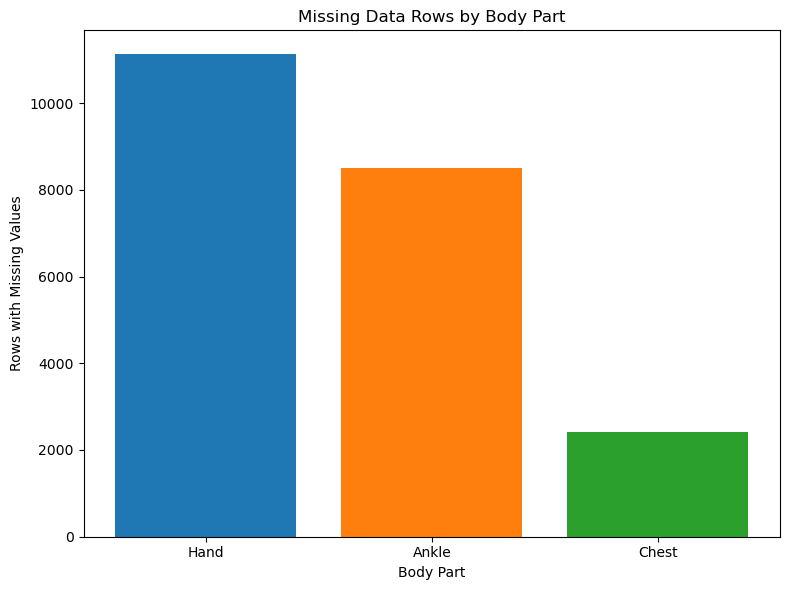

In [47]:
import matplotlib.pyplot as plt

# Sort the data in descending order by value
sorted_items = sorted(missing_rows_by_part.items(), key=lambda x: x[1], reverse=True)
body_parts = [item[0] for item in sorted_items]
missing_values = [item[1] for item in sorted_items]

# Create the figure
plt.figure(figsize=(8, 6))

# Draw the bars one by one with default colors
for i in range(len(body_parts)):
    plt.bar(body_parts[i], missing_values[i])  # Matplotlib assigns default colors automatically

plt.xlabel("Body Part")
plt.ylabel("Rows with Missing Values")
plt.title("Missing Data Rows by Body Part")
plt.xticks()
plt.tight_layout()
plt.show()


En comparación con todas las filas que se tienen, en realidad el porcentaje de faltantes incluso del que más faltantes tiene es despreciable (menos de 1%). Esto dado que tenemos 1,936,481 de filas en el dataset, y las faltantes de la mano son solo 11,122. Esto es exactamente 0.574%, ni siquiera un 0.6%. Las demás son incluso menores. 

In [49]:
import pandas as pd

# Definir las partes del cuerpo
body_parts = ['Hand', 'Chest', 'Ankle']

# Calcular cuántas filas tienen al menos un valor faltante por parte del cuerpo
missing_rows_by_part = {
    part: pamap_data_filtered.filter(regex=part).isnull().any(axis=1).sum()
    for part in body_parts
}

# Calcular el total de filas en el dataset
total_rows = pamap_data_filtered.shape[0]

# Calcular el ratio de faltantes y el porcentaje de faltantes
ratios = {part: count / total_rows for part, count in missing_rows_by_part.items()}
porcentajes = {part: ratio * 100 for part, ratio in ratios.items()}

# Crear el DataFrame con los resultados
missing_data_by_part = pd.DataFrame({
    'Body Part': list(missing_rows_by_part.keys()),
    'Missing Rows': list(missing_rows_by_part.values()),
    'Missing Percentage': list(porcentajes.values())
})

# Ordenar el DataFrame por 'Missing Rows' de mayor a menor y resetear el índice sin mantener el original
missing_data_by_part = missing_data_by_part.sort_values(by='Missing Rows', ascending=False).reset_index(drop=True)

# Imprimir el total de filas y el DataFrame ordenado sin el índice original
print(f"Total de filas en el dataset: {total_rows}")
print("\nMissing Data by Body Part:")
missing_data_by_part

Total de filas en el dataset: 1936481

Missing Data by Body Part:


,Body Part,Missing Rows,Missing Percentage
0,Hand,11122,0.574
1,Ankle,8504,0.439
2,Chest,2420,0.125


## 3.2 Eliminar valores faltantes: Linear Interpolation

Para el primer método, aplicamos interpolación lineal sobre una deep copy para no modificar el dataset original. 

Las columnas originales completas:

In [53]:
deep_copy_pamap = pamap_data_filtered.copy().infer_objects()
deep_copy_pamap.columns

Index(['timestamp', 'activityID', 'IMU_Hand_acceleration_16g_x',
       'IMU_Hand_acceleration_16g_y', 'IMU_Hand_acceleration_16g_z',
       'IMU_Hand_gyroscope_x', 'IMU_Hand_gyroscope_y', 'IMU_Hand_gyroscope_z',
       'IMU_Hand_magnetometer_x', 'IMU_Hand_magnetometer_y',
       'IMU_Hand_magnetometer_z', 'IMU_Chest_acceleration_16g_x',
       'IMU_Chest_acceleration_16g_y', 'IMU_Chest_acceleration_16g_z',
       'IMU_Chest_gyroscope_x', 'IMU_Chest_gyroscope_y',
       'IMU_Chest_gyroscope_z', 'IMU_Chest_magnetometer_x',
       'IMU_Chest_magnetometer_y', 'IMU_Chest_magnetometer_z',
       'IMU_Ankle_acceleration_16g_x', 'IMU_Ankle_acceleration_16g_y',
       'IMU_Ankle_acceleration_16g_z', 'IMU_Ankle_gyroscope_x',
       'IMU_Ankle_gyroscope_y', 'IMU_Ankle_gyroscope_z',
       'IMU_Ankle_magnetometer_x', 'IMU_Ankle_magnetometer_y',
       'IMU_Ankle_magnetometer_z', 'subject_id'],
      dtype='object')

Nos quedamos solo con las de sensores:

In [55]:
sensor_columns = [
    'IMU_Hand_acceleration_16g_x', 'IMU_Hand_acceleration_16g_y', 'IMU_Hand_acceleration_16g_z',
    'IMU_Hand_gyroscope_x', 'IMU_Hand_gyroscope_y', 'IMU_Hand_gyroscope_z',
    'IMU_Hand_magnetometer_x', 'IMU_Hand_magnetometer_y', 'IMU_Hand_magnetometer_z',
    'IMU_Chest_acceleration_16g_x', 'IMU_Chest_acceleration_16g_y', 'IMU_Chest_acceleration_16g_z',
    'IMU_Chest_gyroscope_x', 'IMU_Chest_gyroscope_y', 'IMU_Chest_gyroscope_z',
    'IMU_Chest_magnetometer_x', 'IMU_Chest_magnetometer_y', 'IMU_Chest_magnetometer_z',
    'IMU_Ankle_acceleration_16g_x', 'IMU_Ankle_acceleration_16g_y', 'IMU_Ankle_acceleration_16g_z',
    'IMU_Ankle_gyroscope_x', 'IMU_Ankle_gyroscope_y', 'IMU_Ankle_gyroscope_z',
    'IMU_Ankle_magnetometer_x', 'IMU_Ankle_magnetometer_y', 'IMU_Ankle_magnetometer_z'
]


cols_to_interpolate = deep_copy_pamap[sensor_columns].copy()

print("Selected columns:", cols_to_interpolate.columns)

Selected columns: Index(['IMU_Hand_acceleration_16g_x', 'IMU_Hand_acceleration_16g_y',
       'IMU_Hand_acceleration_16g_z', 'IMU_Hand_gyroscope_x',
       'IMU_Hand_gyroscope_y', 'IMU_Hand_gyroscope_z',
       'IMU_Hand_magnetometer_x', 'IMU_Hand_magnetometer_y',
       'IMU_Hand_magnetometer_z', 'IMU_Chest_acceleration_16g_x',
       'IMU_Chest_acceleration_16g_y', 'IMU_Chest_acceleration_16g_z',
       'IMU_Chest_gyroscope_x', 'IMU_Chest_gyroscope_y',
       'IMU_Chest_gyroscope_z', 'IMU_Chest_magnetometer_x',
       'IMU_Chest_magnetometer_y', 'IMU_Chest_magnetometer_z',
       'IMU_Ankle_acceleration_16g_x', 'IMU_Ankle_acceleration_16g_y',
       'IMU_Ankle_acceleration_16g_z', 'IMU_Ankle_gyroscope_x',
       'IMU_Ankle_gyroscope_y', 'IMU_Ankle_gyroscope_z',
       'IMU_Ankle_magnetometer_x', 'IMU_Ankle_magnetometer_y',
       'IMU_Ankle_magnetometer_z'],
      dtype='object')


Aplicamos linear interpolation

In [57]:
cols_to_interpolate.interpolate(method='linear', inplace=True)

print("Data after interpolation:")
cols_to_interpolate.head()

Data after interpolation:


,IMU_Hand_acceleration_16g_x,IMU_Hand_acceleration_16g_y,IMU_Hand_acceleration_16g_z,IMU_Hand_gyroscope_x,IMU_Hand_gyroscope_y,IMU_Hand_gyroscope_z,IMU_Hand_magnetometer_x,IMU_Hand_magnetometer_y,IMU_Hand_magnetometer_z,IMU_Chest_acceleration_16g_x,...,IMU_Chest_magnetometer_z,IMU_Ankle_acceleration_16g_x,IMU_Ankle_acceleration_16g_y,IMU_Ankle_acceleration_16g_z,IMU_Ankle_gyroscope_x,IMU_Ankle_gyroscope_y,IMU_Ankle_gyroscope_z,IMU_Ankle_magnetometer_x,IMU_Ankle_magnetometer_y,IMU_Ankle_magnetometer_z
2928,2.215,8.279,5.588,-0.005,0.038,-0.011,8.932,-67.933,-19.976,0.124,...,44.273,9.739,-1.848,0.095,0.003,-0.028,0.002,-61.108,-36.864,-58.370
2929,2.292,7.673,5.745,-0.172,0.025,-0.010,9.583,-67.958,-20.909,0.201,...,43.543,9.698,-1.884,-0.021,0.021,0.001,0.006,-60.892,-36.320,-58.366
2930,2.291,7.142,5.823,-0.238,0.011,0.001,9.055,-67.402,-19.508,0.270,...,44.026,9.696,-1.922,-0.059,-0.035,-0.052,-0.005,-60.341,-35.784,-58.612
2931,2.218,7.144,5.899,-0.193,0.019,0.013,9.927,-67.439,-20.560,0.237,...,43.657,9.664,-1.847,0.094,-0.033,-0.019,0.027,-60.765,-37.103,-57.880
2932,2.301,7.259,6.093,-0.070,-0.018,0.005,9.156,-67.183,-20.086,0.352,...,42.923,9.776,-1.886,0.096,0.001,-0.049,-0.006,-60.204,-37.123,-57.885


Armamos el nuevo dataset con los interpolados

In [59]:
import pandas as pd

# Identify the non-sensor (additional) columns from the original DataFrame.
other_columns = [col for col in deep_copy_pamap.columns if col not in sensor_columns]

# Extract the remaining columns from the original DataFrame.
other_data = deep_copy_pamap[other_columns].copy()

# Create a new DataFrame that concatenates the additional columns with the interpolated sensor data.
# Here we use pd.concat along the column axis.
interpolated_df = pd.concat([other_data, cols_to_interpolate], axis=1)

# Optionally, display the new DataFrame which now includes both sets of columns.
print("New DataFrame with interpolated sensor columns and additional data:")
interpolated_df.head()

New DataFrame with interpolated sensor columns and additional data:


,timestamp,activityID,subject_id,IMU_Hand_acceleration_16g_x,IMU_Hand_acceleration_16g_y,IMU_Hand_acceleration_16g_z,IMU_Hand_gyroscope_x,IMU_Hand_gyroscope_y,IMU_Hand_gyroscope_z,IMU_Hand_magnetometer_x,...,IMU_Chest_magnetometer_z,IMU_Ankle_acceleration_16g_x,IMU_Ankle_acceleration_16g_y,IMU_Ankle_acceleration_16g_z,IMU_Ankle_gyroscope_x,IMU_Ankle_gyroscope_y,IMU_Ankle_gyroscope_z,IMU_Ankle_magnetometer_x,IMU_Ankle_magnetometer_y,IMU_Ankle_magnetometer_z
2928,37.660,1,subject101,2.215,8.279,5.588,-0.005,0.038,-0.011,8.932,...,44.273,9.739,-1.848,0.095,0.003,-0.028,0.002,-61.108,-36.864,-58.370
2929,37.670,1,subject101,2.292,7.673,5.745,-0.172,0.025,-0.010,9.583,...,43.543,9.698,-1.884,-0.021,0.021,0.001,0.006,-60.892,-36.320,-58.366
2930,37.680,1,subject101,2.291,7.142,5.823,-0.238,0.011,0.001,9.055,...,44.026,9.696,-1.922,-0.059,-0.035,-0.052,-0.005,-60.341,-35.784,-58.612
2931,37.690,1,subject101,2.218,7.144,5.899,-0.193,0.019,0.013,9.927,...,43.657,9.664,-1.847,0.094,-0.033,-0.019,0.027,-60.765,-37.103,-57.880
2932,37.700,1,subject101,2.301,7.259,6.093,-0.070,-0.018,0.005,9.156,...,42.923,9.776,-1.886,0.096,0.001,-0.049,-0.006,-60.204,-37.123,-57.885


In [60]:
interpolated_df.shape

(1936481, 30)

Después de la interplolación, no quedan más faltantes

In [62]:
interpolated_df.isnull().sum()

timestamp                       0
activityID                      0
subject_id                      0
IMU_Hand_acceleration_16g_x     0
IMU_Hand_acceleration_16g_y     0
IMU_Hand_acceleration_16g_z     0
IMU_Hand_gyroscope_x            0
IMU_Hand_gyroscope_y            0
IMU_Hand_gyroscope_z            0
IMU_Hand_magnetometer_x         0
IMU_Hand_magnetometer_y         0
IMU_Hand_magnetometer_z         0
IMU_Chest_acceleration_16g_x    0
IMU_Chest_acceleration_16g_y    0
IMU_Chest_acceleration_16g_z    0
IMU_Chest_gyroscope_x           0
IMU_Chest_gyroscope_y           0
IMU_Chest_gyroscope_z           0
IMU_Chest_magnetometer_x        0
IMU_Chest_magnetometer_y        0
IMU_Chest_magnetometer_z        0
IMU_Ankle_acceleration_16g_x    0
IMU_Ankle_acceleration_16g_y    0
IMU_Ankle_acceleration_16g_z    0
IMU_Ankle_gyroscope_x           0
IMU_Ankle_gyroscope_y           0
IMU_Ankle_gyroscope_z           0
IMU_Ankle_magnetometer_x        0
IMU_Ankle_magnetometer_y        0
IMU_Ankle_magn

# 4. Pre-proceso: Elminar ruido usando Median Filter

Observamos el dataset que vamos a aplicar el filtro:

In [65]:
interpolated_df.head()

,timestamp,activityID,subject_id,IMU_Hand_acceleration_16g_x,IMU_Hand_acceleration_16g_y,IMU_Hand_acceleration_16g_z,IMU_Hand_gyroscope_x,IMU_Hand_gyroscope_y,IMU_Hand_gyroscope_z,IMU_Hand_magnetometer_x,...,IMU_Chest_magnetometer_z,IMU_Ankle_acceleration_16g_x,IMU_Ankle_acceleration_16g_y,IMU_Ankle_acceleration_16g_z,IMU_Ankle_gyroscope_x,IMU_Ankle_gyroscope_y,IMU_Ankle_gyroscope_z,IMU_Ankle_magnetometer_x,IMU_Ankle_magnetometer_y,IMU_Ankle_magnetometer_z
2928,37.660,1,subject101,2.215,8.279,5.588,-0.005,0.038,-0.011,8.932,...,44.273,9.739,-1.848,0.095,0.003,-0.028,0.002,-61.108,-36.864,-58.370
2929,37.670,1,subject101,2.292,7.673,5.745,-0.172,0.025,-0.010,9.583,...,43.543,9.698,-1.884,-0.021,0.021,0.001,0.006,-60.892,-36.320,-58.366
2930,37.680,1,subject101,2.291,7.142,5.823,-0.238,0.011,0.001,9.055,...,44.026,9.696,-1.922,-0.059,-0.035,-0.052,-0.005,-60.341,-35.784,-58.612
2931,37.690,1,subject101,2.218,7.144,5.899,-0.193,0.019,0.013,9.927,...,43.657,9.664,-1.847,0.094,-0.033,-0.019,0.027,-60.765,-37.103,-57.880
2932,37.700,1,subject101,2.301,7.259,6.093,-0.070,-0.018,0.005,9.156,...,42.923,9.776,-1.886,0.096,0.001,-0.049,-0.006,-60.204,-37.123,-57.885


Revisamos las columnas irrelevantes para quitarlas:
- timestamp
- activityID
- subject_id

In [67]:
interpolated_df.columns

Index(['timestamp', 'activityID', 'subject_id', 'IMU_Hand_acceleration_16g_x',
       'IMU_Hand_acceleration_16g_y', 'IMU_Hand_acceleration_16g_z',
       'IMU_Hand_gyroscope_x', 'IMU_Hand_gyroscope_y', 'IMU_Hand_gyroscope_z',
       'IMU_Hand_magnetometer_x', 'IMU_Hand_magnetometer_y',
       'IMU_Hand_magnetometer_z', 'IMU_Chest_acceleration_16g_x',
       'IMU_Chest_acceleration_16g_y', 'IMU_Chest_acceleration_16g_z',
       'IMU_Chest_gyroscope_x', 'IMU_Chest_gyroscope_y',
       'IMU_Chest_gyroscope_z', 'IMU_Chest_magnetometer_x',
       'IMU_Chest_magnetometer_y', 'IMU_Chest_magnetometer_z',
       'IMU_Ankle_acceleration_16g_x', 'IMU_Ankle_acceleration_16g_y',
       'IMU_Ankle_acceleration_16g_z', 'IMU_Ankle_gyroscope_x',
       'IMU_Ankle_gyroscope_y', 'IMU_Ankle_gyroscope_z',
       'IMU_Ankle_magnetometer_x', 'IMU_Ankle_magnetometer_y',
       'IMU_Ankle_magnetometer_z'],
      dtype='object')

Aplicamos el filtro en las columnas de sensores:

In [69]:
from scipy.ndimage import median_filter
import pandas as pd

def medianify_dataframe(df, exclude_columns=None, filter_size=3):
    if exclude_columns is None:
        exclude_columns = []

    df_copy = df.copy()
    columns_for_filter = df.columns.difference(exclude_columns)

    df_filtered = df_copy[columns_for_filter].apply(lambda col: median_filter(col, size=filter_size))
    df_final = pd.concat([df_copy[exclude_columns], df_filtered], axis=1)

    return df_final[df.columns]

In [70]:
pamap_interpol_median = medianify_dataframe(interpolated_df, 
                                 exclude_columns=['activityID', 'subject_id', 'timestamp'], 
                                 filter_size=3)
pamap_interpol_median.head()

,timestamp,activityID,subject_id,IMU_Hand_acceleration_16g_x,IMU_Hand_acceleration_16g_y,IMU_Hand_acceleration_16g_z,IMU_Hand_gyroscope_x,IMU_Hand_gyroscope_y,IMU_Hand_gyroscope_z,IMU_Hand_magnetometer_x,...,IMU_Chest_magnetometer_z,IMU_Ankle_acceleration_16g_x,IMU_Ankle_acceleration_16g_y,IMU_Ankle_acceleration_16g_z,IMU_Ankle_gyroscope_x,IMU_Ankle_gyroscope_y,IMU_Ankle_gyroscope_z,IMU_Ankle_magnetometer_x,IMU_Ankle_magnetometer_y,IMU_Ankle_magnetometer_z
2928,37.660,1,subject101,2.215,8.279,5.588,-0.005,0.038,-0.011,8.932,...,44.273,9.739,-1.848,0.095,0.003,-0.028,0.002,-61.108,-36.864,-58.370
2929,37.670,1,subject101,2.291,7.673,5.745,-0.172,0.025,-0.010,9.055,...,44.026,9.698,-1.884,-0.021,0.003,-0.028,0.002,-60.892,-36.320,-58.370
2930,37.680,1,subject101,2.291,7.144,5.823,-0.193,0.019,0.001,9.583,...,43.657,9.696,-1.884,-0.021,-0.033,-0.019,0.006,-60.765,-36.320,-58.366
2931,37.690,1,subject101,2.291,7.144,5.899,-0.193,0.011,0.005,9.156,...,43.657,9.696,-1.886,0.094,-0.033,-0.049,-0.005,-60.341,-37.103,-57.885
2932,37.700,1,subject101,2.218,7.259,6.012,-0.070,0.007,0.013,9.156,...,43.657,9.664,-1.886,0.094,0.001,-0.027,0.004,-60.765,-37.103,-57.880


Observamos la diferencia y notamos que se reduce en los puntos más extremos

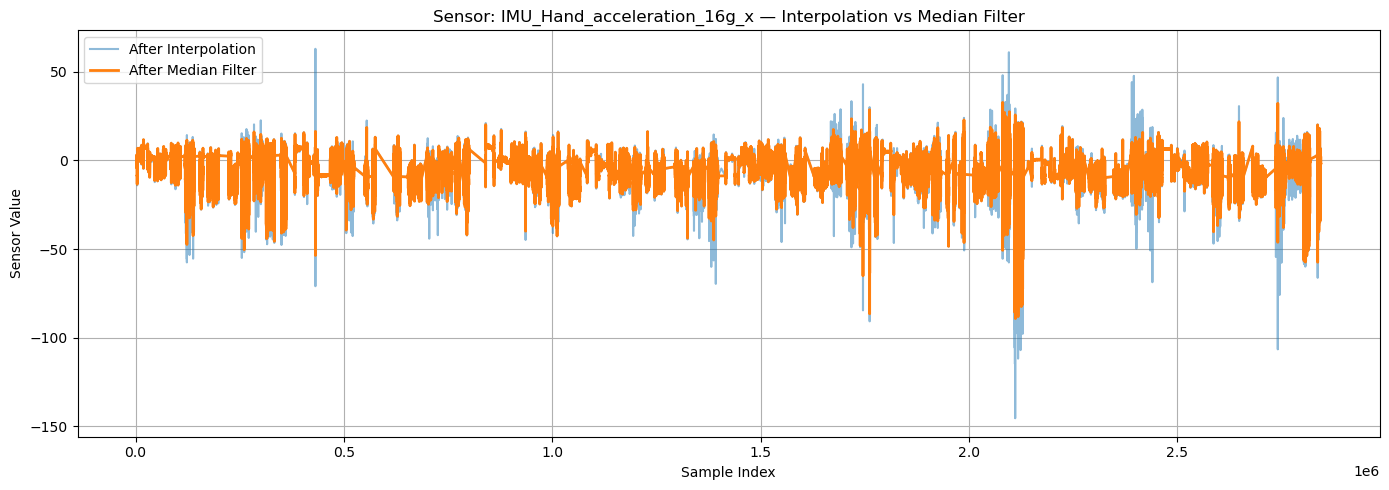

In [72]:
import matplotlib.pyplot as plt

# Choose a sensor column to visualize
sensor_column = 'IMU_Hand_acceleration_16g_x'

# Extract signals
original = interpolated_df[sensor_column]
medianed = pamap_interpol_median[sensor_column]

# Plot comparison
plt.figure(figsize=(14, 5))
plt.plot(original, label='After Interpolation', alpha=0.5)
plt.plot(medianed, label='After Median Filter', linewidth=2)
plt.title(f'Sensor: {sensor_column} — Interpolation vs Median Filter')
plt.xlabel('Sample Index')
plt.ylabel('Sensor Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Para observar bien los efectos anaizamos una ventana de tiempo de 300 (equivalente a 3s dado que son 100Hz).

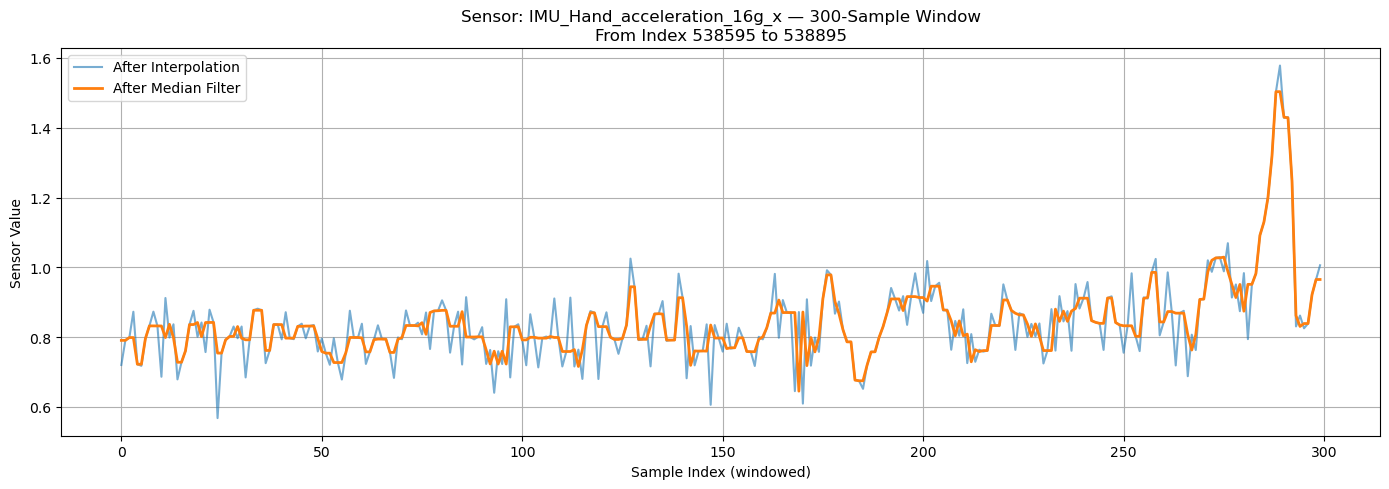

In [74]:
import numpy as np
import matplotlib.pyplot as plt

# Choose the sensor column
sensor_column = 'IMU_Hand_acceleration_16g_x'

# Total number of samples available
total_samples = len(interpolated_df)

# Choose random starting index such that we can take 300 samples without going out of bounds
start_idx = np.random.randint(0, total_samples - 300)

# Slice the 300-sample window
original = interpolated_df[sensor_column].iloc[start_idx:start_idx + 300]
medianed = pamap_interpol_median[sensor_column].iloc[start_idx:start_idx + 300]

# Plot
plt.figure(figsize=(14, 5))
plt.plot(original.values, label='After Interpolation', alpha=0.6)
plt.plot(medianed.values, label='After Median Filter', linewidth=2)
plt.title(f'Sensor: {sensor_column} — 300-Sample Window\nFrom Index {start_idx} to {start_idx + 300}')
plt.xlabel('Sample Index (windowed)')
plt.ylabel('Sensor Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# 5. Segmentación 

In [76]:
import pandas as pd

def segment_by_window(group, window_size):
    """
    Segments data into windows of specified size.

    Args:
        group (pd.DataFrame): Subject's data.
        window_size (int): Size of each time window.

    Returns:
        list: List of DataFrames, each representing a window of data.
    """
    windows = []
    for start in range(0, len(group), window_size):
        end = start + window_size
        if end <= len(group):
            window = group.iloc[start:end].copy()
            windows.append(window)
    return windows

def add_window_metadata(windows, subject_id):
    """
    Adds metadata like window number, window ID, and majority label.

    Args:
        windows (list): List of window DataFrames.
        subject_id (int): Subject identifier.

    Returns:
        list: List of windows with added metadata.
    """
    for i, window in enumerate(windows):
        window['subject_id'] = subject_id
        window['window_number'] = i
        window['window_id'] = f"{subject_id}_{window['window_number'].iloc[0]}"

        majority_label = get_majority_label(window)
        window['labels_in_window'] = [majority_label] * len(window)
    return windows

def get_majority_label(window):
    """
    Gets the majority label for a window.

    Args:
        window (pd.DataFrame): Window data.

    Returns:
        str: Majority label, or fallback to first label if no clear majority.
    """
    label_counts = window['activityID'].value_counts()
    majority_label = (
        label_counts.idxmax()
        if label_counts.max() / len(window) > 0.5
        else window['activityID'].iloc[0]
    )
    return majority_label

def process_subject_data(mhealth_df, window_size):
    """
    Processes all subject data by segmenting and adding metadata.

    Args:
        mhealth_df (pd.DataFrame): Data of multiple subjects.
        window_size (int): Size of each time window.

    Returns:
        list: List of windows with metadata.
    """
    all_windows = []
    for subject_id, group in mhealth_df.groupby('subject_id'):
        group = group.reset_index(drop=True)
        windows = segment_by_window(group, window_size)
        windows = add_window_metadata(windows, subject_id)
        all_windows.extend(windows)
    return all_windows

def concatenate_windows(windows):
    """
    Concatenates all windows into a single DataFrame.

    Args:
        windows (list): List of window DataFrames.

    Returns:
        pd.DataFrame: Concatenated DataFrame of all windows.
    """
    return pd.concat(windows).reset_index(drop=True)

def display_basic_info(ventanas_df, windows):
    """
    Displays basic info about windows and their majority labels.

    Args:
        ventanas_df (pd.DataFrame): DataFrame of windows with metadata.
        windows (list): List of processed windows.
    """
    for window_id, group in ventanas_df.groupby('window_id'):
        majority_label = group['labels_in_window'].iloc[0]
        print(f"Window {window_id}: majority label = {majority_label}")

# Parameters
window_size = 300  # 3 seconds * 100 Hz

print(pamap_data.shape)
windows = process_subject_data(pamap_interpol_median, window_size)

# Concatenate all windows into a single DataFrame
pamap_windowed = concatenate_windows(windows)

(1936481, 55)


In [77]:
pamap_windowed.head()

,timestamp,activityID,subject_id,IMU_Hand_acceleration_16g_x,IMU_Hand_acceleration_16g_y,IMU_Hand_acceleration_16g_z,IMU_Hand_gyroscope_x,IMU_Hand_gyroscope_y,IMU_Hand_gyroscope_z,IMU_Hand_magnetometer_x,...,IMU_Ankle_acceleration_16g_z,IMU_Ankle_gyroscope_x,IMU_Ankle_gyroscope_y,IMU_Ankle_gyroscope_z,IMU_Ankle_magnetometer_x,IMU_Ankle_magnetometer_y,IMU_Ankle_magnetometer_z,window_number,window_id,labels_in_window
0,37.660,1,subject101,2.215,8.279,5.588,-0.005,0.038,-0.011,8.932,...,0.095,0.003,-0.028,0.002,-61.108,-36.864,-58.370,0,subject101_0,1
1,37.670,1,subject101,2.291,7.673,5.745,-0.172,0.025,-0.010,9.055,...,-0.021,0.003,-0.028,0.002,-60.892,-36.320,-58.370,0,subject101_0,1
2,37.680,1,subject101,2.291,7.144,5.823,-0.193,0.019,0.001,9.583,...,-0.021,-0.033,-0.019,0.006,-60.765,-36.320,-58.366,0,subject101_0,1
3,37.690,1,subject101,2.291,7.144,5.899,-0.193,0.011,0.005,9.156,...,0.094,-0.033,-0.049,-0.005,-60.341,-37.103,-57.885,0,subject101_0,1
4,37.700,1,subject101,2.218,7.259,6.012,-0.070,0.007,0.013,9.156,...,0.094,0.001,-0.027,0.004,-60.765,-37.103,-57.880,0,subject101_0,1


In [78]:
pamap_windowed

,timestamp,activityID,subject_id,IMU_Hand_acceleration_16g_x,IMU_Hand_acceleration_16g_y,IMU_Hand_acceleration_16g_z,IMU_Hand_gyroscope_x,IMU_Hand_gyroscope_y,IMU_Hand_gyroscope_z,IMU_Hand_magnetometer_x,...,IMU_Ankle_acceleration_16g_z,IMU_Ankle_gyroscope_x,IMU_Ankle_gyroscope_y,IMU_Ankle_gyroscope_z,IMU_Ankle_magnetometer_x,IMU_Ankle_magnetometer_y,IMU_Ankle_magnetometer_z,window_number,window_id,labels_in_window
0,37.660,1,subject101,2.215,8.279,5.588,-0.005,0.038,-0.011,8.932,...,0.095,0.003,-0.028,0.002,-61.108,-36.864,-58.370,0,subject101_0,1
1,37.670,1,subject101,2.291,7.673,5.745,-0.172,0.025,-0.010,9.055,...,-0.021,0.003,-0.028,0.002,-60.892,-36.320,-58.370,0,subject101_0,1
2,37.680,1,subject101,2.291,7.144,5.823,-0.193,0.019,0.001,9.583,...,-0.021,-0.033,-0.019,0.006,-60.765,-36.320,-58.366,0,subject101_0,1
3,37.690,1,subject101,2.291,7.144,5.899,-0.193,0.011,0.005,9.156,...,0.094,-0.033,-0.049,-0.005,-60.341,-37.103,-57.885,0,subject101_0,1
4,37.700,1,subject101,2.218,7.259,6.012,-0.070,0.007,0.013,9.156,...,0.094,0.001,-0.027,0.004,-60.765,-37.103,-57.880,0,subject101_0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1935295,3886.350,24,subject108,0.514,-10.041,0.622,0.051,-0.047,-0.033,-5.488,...,-3.629,0.097,0.014,0.009,-32.125,13.409,39.432,872,subject108_872,24
1935296,3886.360,24,subject108,0.482,-10.077,0.732,0.110,-0.011,-0.053,-5.490,...,-3.629,0.078,0.011,0.030,-32.125,13.409,39.432,872,subject108_872,24
1935297,3886.370,24,subject108,0.186,-10.187,0.774,0.116,-0.002,-0.073,-5.748,...,-3.702,-0.002,-0.004,0.065,-31.224,13.108,39.432,872,subject108_872,24
1935298,3886.380,24,subject108,0.186,-10.187,0.962,0.153,0.015,-0.078,-5.620,...,-3.738,-0.006,-0.022,0.065,-31.224,13.108,39.292,872,subject108_872,24


In [79]:
pamap_windowed.shape

(1935300, 33)

In [80]:
pamap_windowed.columns

Index(['timestamp', 'activityID', 'subject_id', 'IMU_Hand_acceleration_16g_x',
       'IMU_Hand_acceleration_16g_y', 'IMU_Hand_acceleration_16g_z',
       'IMU_Hand_gyroscope_x', 'IMU_Hand_gyroscope_y', 'IMU_Hand_gyroscope_z',
       'IMU_Hand_magnetometer_x', 'IMU_Hand_magnetometer_y',
       'IMU_Hand_magnetometer_z', 'IMU_Chest_acceleration_16g_x',
       'IMU_Chest_acceleration_16g_y', 'IMU_Chest_acceleration_16g_z',
       'IMU_Chest_gyroscope_x', 'IMU_Chest_gyroscope_y',
       'IMU_Chest_gyroscope_z', 'IMU_Chest_magnetometer_x',
       'IMU_Chest_magnetometer_y', 'IMU_Chest_magnetometer_z',
       'IMU_Ankle_acceleration_16g_x', 'IMU_Ankle_acceleration_16g_y',
       'IMU_Ankle_acceleration_16g_z', 'IMU_Ankle_gyroscope_x',
       'IMU_Ankle_gyroscope_y', 'IMU_Ankle_gyroscope_z',
       'IMU_Ankle_magnetometer_x', 'IMU_Ankle_magnetometer_y',
       'IMU_Ankle_magnetometer_z', 'window_number', 'window_id',
       'labels_in_window'],
      dtype='object')

# 6. Imbalance de clases: análisis

There's a pronounced class imbalance with the class 24, 5, 13 and 12

In [83]:
# Count and sort samples per activity using 'labels_in_window'
activity_counts = pamap_windowed['labels_in_window'].value_counts().sort_values(ascending=False)

# Display the result
activity_counts

labels_in_window
17    238500
4     238200
1     192600
3     189600
7     188100
2     185400
16    175500
6     164700
12    117300
13    105300
5      97800
24     42300
Name: count, dtype: int64

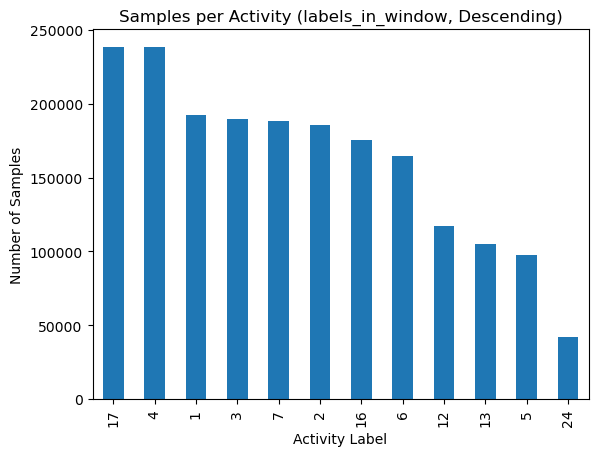

In [84]:
activity_counts.plot(kind='bar')
plt.xlabel('Activity Label')
plt.ylabel('Number of Samples')
plt.title('Samples per Activity (labels_in_window, Descending)')
plt.show()

# 7. Extracción de características

In [86]:
pamap_windowed.columns

Index(['timestamp', 'activityID', 'subject_id', 'IMU_Hand_acceleration_16g_x',
       'IMU_Hand_acceleration_16g_y', 'IMU_Hand_acceleration_16g_z',
       'IMU_Hand_gyroscope_x', 'IMU_Hand_gyroscope_y', 'IMU_Hand_gyroscope_z',
       'IMU_Hand_magnetometer_x', 'IMU_Hand_magnetometer_y',
       'IMU_Hand_magnetometer_z', 'IMU_Chest_acceleration_16g_x',
       'IMU_Chest_acceleration_16g_y', 'IMU_Chest_acceleration_16g_z',
       'IMU_Chest_gyroscope_x', 'IMU_Chest_gyroscope_y',
       'IMU_Chest_gyroscope_z', 'IMU_Chest_magnetometer_x',
       'IMU_Chest_magnetometer_y', 'IMU_Chest_magnetometer_z',
       'IMU_Ankle_acceleration_16g_x', 'IMU_Ankle_acceleration_16g_y',
       'IMU_Ankle_acceleration_16g_z', 'IMU_Ankle_gyroscope_x',
       'IMU_Ankle_gyroscope_y', 'IMU_Ankle_gyroscope_z',
       'IMU_Ankle_magnetometer_x', 'IMU_Ankle_magnetometer_y',
       'IMU_Ankle_magnetometer_z', 'window_number', 'window_id',
       'labels_in_window'],
      dtype='object')

In [87]:
import numpy as np

class InertialSensor:
    def __init__(self, x, y, z):
        """
        Inicializa el acelerómetro con sus 3 señales.
        
        Parámetros:
          x: array-like, señal del eje x.
          y: array-like, señal del eje y.
          z: array-like, señal del eje z.
        """
        self.x = np.array(x)
        self.y = np.array(y)
        self.z = np.array(z)
        
    def compute_magnitude(self):
        return np.sqrt(self.x**2 + self.y**2 + self.z**2)
    
    def extract_features(self):
        # 1. Medias de cada eje
        mean_x = np.mean(self.x)
        mean_y = np.mean(self.y)
        mean_z = np.mean(self.z)
        
        # 2. Desviaciones estándar
        std_x = np.std(self.x)
        std_y = np.std(self.y)
        std_z = np.std(self.z)
        
        # 3. Valores máximos
        max_x = np.max(self.x)
        max_y = np.max(self.y)
        max_z = np.max(self.z)
        
        # 4. Correlaciones entre cada par de ejes
        corr_xy = np.corrcoef(self.x, self.y)[0, 1]
        corr_xz = np.corrcoef(self.x, self.z)[0, 1]
        corr_yz = np.corrcoef(self.y, self.z)[0, 1]
        
        # 5,6,7,8. Features derivadas de la magnitud
        magnitude = self.compute_magnitude()
        mean_magnitude = np.mean(magnitude)
        std_magnitude = np.std(magnitude)
        auc = np.sum(magnitude)
        mean_diff = np.mean(np.diff(magnitude)) if len(magnitude) > 1 else 0.0
        
        # Vector de features
        feature_vector = np.array([
            mean_x, mean_y, mean_z,
            std_x, std_y, std_z,
            max_x, max_y, max_z,
            corr_xy, corr_xz, corr_yz,
            mean_magnitude, std_magnitude, auc, mean_diff
        ])
        
        return feature_vector

In [88]:
import numpy as np
import pandas as pd

# Define sensor mappings
sensor_mappings = {
    'Hand': {
        'acc': ['IMU_Hand_acceleration_16g_x', 'IMU_Hand_acceleration_16g_y', 'IMU_Hand_acceleration_16g_z'],
        'gyro': ['IMU_Hand_gyroscope_x', 'IMU_Hand_gyroscope_y', 'IMU_Hand_gyroscope_z'],
        'mag': ['IMU_Hand_magnetometer_x', 'IMU_Hand_magnetometer_y', 'IMU_Hand_magnetometer_z']
    },
    'Chest': {
        'acc': ['IMU_Chest_acceleration_16g_x', 'IMU_Chest_acceleration_16g_y', 'IMU_Chest_acceleration_16g_z'],
        'gyro': ['IMU_Chest_gyroscope_x', 'IMU_Chest_gyroscope_y', 'IMU_Chest_gyroscope_z'],
        'mag': ['IMU_Chest_magnetometer_x', 'IMU_Chest_magnetometer_y', 'IMU_Chest_magnetometer_z']
    },
    'Ankle': {
        'acc': ['IMU_Ankle_acceleration_16g_x', 'IMU_Ankle_acceleration_16g_y', 'IMU_Ankle_acceleration_16g_z'],
        'gyro': ['IMU_Ankle_gyroscope_x', 'IMU_Ankle_gyroscope_y', 'IMU_Ankle_gyroscope_z'],
        'mag': ['IMU_Ankle_magnetometer_x', 'IMU_Ankle_magnetometer_y', 'IMU_Ankle_magnetometer_z']
    }
}

# Define feature names
feature_names = [
    "mean_x", "mean_y", "mean_z", "std_x", "std_y", "std_z",
    "max_x", "max_y", "max_z", "corr_xy", "corr_xz", "corr_yz",
    "mean_mag", "std_mag", "auc", "mean_diff"
]

# Generate feature columns
feature_columns = [
    f"{sensor}_{sensor_type}_{feature}"
    for sensor in sensor_mappings
    for sensor_type in sensor_mappings[sensor]
    for feature in feature_names
]

# Initialize lists to store features, labels y subject_ids
numeric_features_list = []
labels = []
subject_ids = []

# Group data by subject, activity, and window number
grouped = pamap_windowed.groupby(['subject_id', 'labels_in_window', 'window_number'])

# Iterate over each group
for (subject_id, activity_label, window_number), group in grouped:
    feature_vector = []

    for sensor_location, sensor_types in sensor_mappings.items():
        for sensor_type, axes in sensor_types.items():
            # Extract sensor data
            x = group[axes[0]].values
            y = group[axes[1]].values
            z = group[axes[2]].values

            # Compute features using InertialSensor class
            features = InertialSensor(x, y, z).extract_features()
            feature_vector.extend(features)

    # Append features, label y subject_id
    numeric_features_list.append(feature_vector)
    labels.append(activity_label)
    subject_ids.append(subject_id)

# Crear DataFrames
df_subject = pd.DataFrame(subject_ids, columns=["subject_id"])
df_numeric = pd.DataFrame(numeric_features_list, columns=feature_columns)
df_labels  = pd.DataFrame(labels, columns=["activity"])

# Concatenar subject_id, features y labels
examples_db = pd.concat([df_subject, df_numeric, df_labels], axis=1)

# Mostrar resultado
examples_db.head()

,subject_id,Hand_acc_mean_x,Hand_acc_mean_y,Hand_acc_mean_z,Hand_acc_std_x,Hand_acc_std_y,Hand_acc_std_z,Hand_acc_max_x,Hand_acc_max_y,Hand_acc_max_z,...,Ankle_mag_max_y,Ankle_mag_max_z,Ankle_mag_corr_xy,Ankle_mag_corr_xz,Ankle_mag_corr_yz,Ankle_mag_mean_mag,Ankle_mag_std_mag,Ankle_mag_auc,Ankle_mag_mean_diff,activity
0,subject101,-0.046,8.142,4.661,1.915,1.429,1.829,3.089,11.615,8.316,...,-35.508,-57.613,-0.938,-0.555,0.347,92.237,0.330,27671.160,0.000,1
1,subject101,-1.369,8.451,4.250,0.988,1.653,1.932,0.842,12.337,7.474,...,-40.699,-58.204,-0.733,-0.487,0.345,92.571,0.311,27771.406,0.002,1
2,subject101,-0.895,8.675,1.951,2.275,0.936,3.266,2.815,11.479,6.351,...,-40.242,-42.089,0.265,-0.727,-0.845,93.447,1.277,28034.118,0.015,1
3,subject101,-6.479,2.705,3.806,3.681,4.182,3.236,2.716,9.833,8.228,...,42.984,-4.975,0.786,0.867,0.890,76.927,26.819,23078.155,-0.169,1
4,subject101,0.322,5.569,7.938,0.571,1.053,0.747,3.139,7.695,10.102,...,44.947,-8.739,0.931,0.702,0.896,46.565,0.544,13969.563,0.004,1


In [89]:
examples_db.shape

(6451, 146)

Esperamos tener 140 columnas de características + 1 columna de la etiqueta de la actividad + id del sujeto

- (16 características por sensor) (3 sensores) + 1 label = 144 features + 1 label + id del sujeto = 146 columnas

In [91]:
print(examples_db.dtypes.to_string())

subject_id               object
Hand_acc_mean_x         float64
Hand_acc_mean_y         float64
Hand_acc_mean_z         float64
Hand_acc_std_x          float64
Hand_acc_std_y          float64
Hand_acc_std_z          float64
Hand_acc_max_x          float64
Hand_acc_max_y          float64
Hand_acc_max_z          float64
Hand_acc_corr_xy        float64
Hand_acc_corr_xz        float64
Hand_acc_corr_yz        float64
Hand_acc_mean_mag       float64
Hand_acc_std_mag        float64
Hand_acc_auc            float64
Hand_acc_mean_diff      float64
Hand_gyro_mean_x        float64
Hand_gyro_mean_y        float64
Hand_gyro_mean_z        float64
Hand_gyro_std_x         float64
Hand_gyro_std_y         float64
Hand_gyro_std_z         float64
Hand_gyro_max_x         float64
Hand_gyro_max_y         float64
Hand_gyro_max_z         float64
Hand_gyro_corr_xy       float64
Hand_gyro_corr_xz       float64
Hand_gyro_corr_yz       float64
Hand_gyro_mean_mag      float64
Hand_gyro_std_mag       float64
Hand_gyr

In [92]:
counts = examples_db.groupby('subject_id').size().sort_index()
counts

subject_id
subject101    833
subject102    877
subject103    581
subject104    771
subject105    908
subject106    833
subject107    775
subject108    873
dtype: int64

# 8. Estandarización

Se usa z-score

In [95]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# 9. Train/Test con CV: Ejemplo Bootstrap

Importamos la pipeline para hacerlo

In [98]:
from imblearn.pipeline import make_pipeline

Separamos los ejemplos de los labels

In [100]:
X = examples_db.drop(columns=["activity", "subject_id"], errors="ignore")
y = examples_db["activity"]

# Codificar etiquetas si es necesario (por ejemplo, si activity no es numérica)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

Usamos NB para bootstrapping

In [102]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()

Fitteamos el modelo

In [104]:
pipe1 = make_pipeline(
    scaler, 
    nb
)

pipe1.fit(X, y_encoded)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('gaussiannb', GaussianNB())])

Aplicamos el CV para obtener resultados

In [106]:
from sklearn.model_selection import cross_val_score

scorespipe = cross_val_score(pipe1, X, y_encoded, cv=10, scoring="f1_macro")
scorespipe

array([0.73936985, 0.88517351, 0.86413782, 0.8854679 , 0.89963603,
       0.82984083, 0.8423169 , 0.86949689, 0.84130163, 0.83883103])

In [107]:
np.average(scorespipe)

0.8495572382481328

# 10. Entrenamiento y evaluación: Comparación K-Fold y LOSO CV

## 10.1. K-Fold Cross Validation (KFCV)

In [110]:
X = examples_db.drop(columns=["activity", "subject_id"], errors="ignore")
y = examples_db["activity"]

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [111]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.pipeline import make_pipeline
from imblearn.over_sampling import SMOTE

def pipeleanear(model, X, y, n_splits=10): 
    # definimos la estrategia del stratified k fold para que lo shufflee los ejemplos y que haga 10 splits y que sea estratificado
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    pipeline = make_pipeline(
        # Auto es el parámetro POR DEFECTO, lo que significa que si no le pasas nada, se aplica ese parámetro. 
        SMOTE(sampling_strategy='all', random_state=42), 
        scaler,  
        model
    )
    
    scores = cross_val_score(pipeline, X, y, cv=skf, scoring="f1_macro")

    print("F1 Macro Score por ronda de Stratified Cross-Validation (10 folds):")
    for i, score in enumerate(scores, 1):
        print(f"  Ronda {i}: {score:.4f}")
    
    avg_score = np.mean(scores)
    print(f"\nPromedio F1 Macro Score: {avg_score:.4f}")
    
    return scores

### 10.1.1 NB

In [113]:
from sklearn.naive_bayes import GaussianNB
nb_1 = GaussianNB()
nb_results_kfold = pipeleanear(nb_1, X, y)

F1 Macro Score por ronda de Stratified Cross-Validation (10 folds):
  Ronda 1: 0.8835
  Ronda 2: 0.8993
  Ronda 3: 0.8826
  Ronda 4: 0.8722
  Ronda 5: 0.8905
  Ronda 6: 0.8849
  Ronda 7: 0.8815
  Ronda 8: 0.8873
  Ronda 9: 0.8808
  Ronda 10: 0.8729

Promedio F1 Macro Score: 0.8836


### 10.1.2 LB

In [115]:
from sklearn.linear_model import LogisticRegression
lr_1 = LogisticRegression(max_iter=1000)
lr_results_kfold = pipeleanear(lr_1, X, y_encoded)

F1 Macro Score por ronda de Stratified Cross-Validation (10 folds):
  Ronda 1: 0.9171
  Ronda 2: 0.9347
  Ronda 3: 0.9281
  Ronda 4: 0.9156
  Ronda 5: 0.9275
  Ronda 6: 0.9107
  Ronda 7: 0.9414
  Ronda 8: 0.9239
  Ronda 9: 0.9055
  Ronda 10: 0.9269

Promedio F1 Macro Score: 0.9231


### 10.1.3 MLP

In [117]:
from sklearn.linear_model import Perceptron
perceptron_1 = Perceptron()
percep_results_kfold = pipeleanear(perceptron_1, X, y_encoded)

F1 Macro Score por ronda de Stratified Cross-Validation (10 folds):
  Ronda 1: 0.8927
  Ronda 2: 0.9329
  Ronda 3: 0.8971
  Ronda 4: 0.8974
  Ronda 5: 0.8973
  Ronda 6: 0.8916
  Ronda 7: 0.9132
  Ronda 8: 0.9006
  Ronda 9: 0.8899
  Ronda 10: 0.8968

Promedio F1 Macro Score: 0.9010


### 10.1.4 RF

In [119]:
from sklearn.ensemble import RandomForestClassifier
rf_1 = RandomForestClassifier()
rf_results_kfold = pipeleanear(rf_1, X, y_encoded)

F1 Macro Score por ronda de Stratified Cross-Validation (10 folds):
  Ronda 1: 0.9300
  Ronda 2: 0.9564
  Ronda 3: 0.9424
  Ronda 4: 0.9220
  Ronda 5: 0.9390
  Ronda 6: 0.9436
  Ronda 7: 0.9516
  Ronda 8: 0.9372
  Ronda 9: 0.9421
  Ronda 10: 0.9406

Promedio F1 Macro Score: 0.9405


### 10.1.5 XGBoost

In [121]:
from xgboost import XGBClassifier
xgb_1 = XGBClassifier()
xgb_results_kfold = pipeleanear(xgb_1, X, y_encoded)

F1 Macro Score por ronda de Stratified Cross-Validation (10 folds):
  Ronda 1: 0.9435
  Ronda 2: 0.9580
  Ronda 3: 0.9428
  Ronda 4: 0.9460
  Ronda 5: 0.9505
  Ronda 6: 0.9395
  Ronda 7: 0.9587
  Ronda 8: 0.9491
  Ronda 9: 0.9459
  Ronda 10: 0.9579

Promedio F1 Macro Score: 0.9492


Resultados

In [123]:
import pandas as pd

# Crear el diccionario con los resultados promedio de cada modelo
results_dict = {
    "Naive Bayes": np.mean(nb_results_kfold),
    "Logistic Regression": np.mean(lr_results_kfold),
    "Perceptron": np.mean(percep_results_kfold),
    "Random Forest": np.mean(rf_results_kfold),
    "XGBoost": np.mean(xgb_results_kfold),
}

# Crear el DataFrame
results_df_1 = pd.DataFrame.from_dict(results_dict, orient='index', columns=["F1 Score"])
results_df_1.index.name = "Classifier"

# Mostrar resultados ordenados (opcional)
results_df_kfold = results_df_1.sort_values(by="F1 Score", ascending=False)

results_df_kfold

,F1 Score
Classifier,
XGBoost,0.949
Random Forest,0.940
Logistic Regression,0.923
Perceptron,0.901
Naive Bayes,0.884


## 10.2. LOSO: Group-8-Fold Cross Validation

In [125]:
groups = examples_db["subject_id"]
groups.nunique()

8

Pipeline:

In [127]:
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
from imblearn.pipeline import make_pipeline
from imblearn.over_sampling import SMOTE

def pipelinear_loso(model, X, y, groups, n_splits=8): 
    # Usamos StratifiedGroupKFold para estratificación por clase y separación por grupo
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)

    pipeline = make_pipeline(
        SMOTE(sampling_strategy='all', random_state=42), 
        scaler,  
        model
    )
    
    scores = cross_val_score(pipeline, X, y, groups=groups, cv=sgkf, scoring="f1_macro")

    print("F1 Macro Score por ronda de StratifiedGroupKFold Cross-Validation (8 grupos):")
    for i, score in enumerate(scores, 1):
        print(f"  Ronda {i}: {score:.4f}")
    
    avg_score = np.mean(scores)
    print(f"\nPromedio F1 Macro Score: {avg_score:.4f}")
    
    return scores

### 10.2.1. NB

In [129]:
# Obtener los datos
X = examples_db.drop(columns=["activity", "subject_id"], errors="ignore")
y = examples_db.activity
groups = examples_db["subject_id"]

# Encodear los labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Armar el modelo: Gaussian Naive Bayes
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()

# Correr Leave-One-Subject-Out con Naive Bayes
nb_loso = pipelinear_loso(
    model=model,
    X=X,
    y=y_encoded,
    groups=groups,
)


F1 Macro Score por ronda de StratifiedGroupKFold Cross-Validation (8 grupos):
  Ronda 1: 0.8325
  Ronda 2: 0.6780
  Ronda 3: 0.8823
  Ronda 4: 0.7334
  Ronda 5: 0.7989
  Ronda 6: 0.8274
  Ronda 7: 0.5809
  Ronda 8: 0.7367

Promedio F1 Macro Score: 0.7588


### 10.2.2. LR

In [131]:
# Obtener los datos
X = examples_db.drop(columns=["activity", "subject_id"], errors="ignore")
y = examples_db.activity
groups = examples_db["subject_id"]

# encodear los labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# armar el modelo
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=10000)


lr_loso = pipelinear_loso(
    model=model,
    X=X,                
    y=y_encoded,        
    groups=groups,     
)

F1 Macro Score por ronda de StratifiedGroupKFold Cross-Validation (8 grupos):
  Ronda 1: 0.8241
  Ronda 2: 0.4178
  Ronda 3: 0.8253
  Ronda 4: 0.7942
  Ronda 5: 0.7734
  Ronda 6: 0.8839
  Ronda 7: 0.6290
  Ronda 8: 0.7782

Promedio F1 Macro Score: 0.7407


### 10.2.3. MLP

In [133]:
X = examples_db.drop(columns=["activity", "subject_id"], errors="ignore")
y = examples_db.activity
groups = examples_db["subject_id"]

# encodear los labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)


from sklearn.linear_model import Perceptron
model = Perceptron()

mlp_loso = pipelinear_loso(
    model=model,
    X=X,                
    y=y_encoded,        
    groups=groups,     
)

F1 Macro Score por ronda de StratifiedGroupKFold Cross-Validation (8 grupos):
  Ronda 1: 0.8131
  Ronda 2: 0.4379
  Ronda 3: 0.8389
  Ronda 4: 0.7807
  Ronda 5: 0.7531
  Ronda 6: 0.7111
  Ronda 7: 0.6608
  Ronda 8: 0.6052

Promedio F1 Macro Score: 0.7001


### 10.2.4. RF

In [135]:
X = examples_db.drop(columns=["activity", "subject_id"], errors="ignore")
y = examples_db.activity
groups = examples_db["subject_id"]

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)


from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(
    max_depth=None,       
    random_state=42,      
    n_jobs=-1            
)


rf_loso = pipelinear_loso(
    model=model_rf,
    X=X,
    y=y_encoded,
    groups=groups,
)


F1 Macro Score por ronda de StratifiedGroupKFold Cross-Validation (8 grupos):
  Ronda 1: 0.9143
  Ronda 2: 0.7205
  Ronda 3: 0.9281
  Ronda 4: 0.8685
  Ronda 5: 0.9141
  Ronda 6: 0.9077
  Ronda 7: 0.6914
  Ronda 8: 0.8159

Promedio F1 Macro Score: 0.8450


### 10.2.5. XGBoost

In [137]:
# 1. Preparar datos (igual que antes)
X = examples_db.drop(columns=["activity", "subject_id"], errors="ignore")
y = examples_db.activity
groups = examples_db["subject_id"]

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 2. Instanciar XGBClassifier
from xgboost import XGBClassifier
model_xgb = XGBClassifier(
    n_estimators=100,        # número de rondas de boosting
    max_depth=6,             # profundidad máxima de cada árbol
    learning_rate=0.1,       # tasa de aprendizaje
    objective='multi:softprob',  # para clasificación multiclase
    eval_metric='mlogloss',  # métrica de evaluación
    random_state=42,
    n_jobs=-1
)

# 3. Ejecutar LO-SO CV con XGBoost
xgb_loso = pipelinear_loso(
    model=model_xgb,
    X=X,
    y=y_encoded,
    groups=groups,
)

F1 Macro Score por ronda de StratifiedGroupKFold Cross-Validation (8 grupos):
  Ronda 1: 0.8571
  Ronda 2: 0.6575
  Ronda 3: 0.9351
  Ronda 4: 0.7592
  Ronda 5: 0.9292
  Ronda 6: 0.8840
  Ronda 7: 0.6797
  Ronda 8: 0.8271

Promedio F1 Macro Score: 0.8161


In [138]:
import pandas as pd

results_dict = {
    "Naive Bayes": np.mean(nb_loso),
    "Logistic Regression": np.mean(lr_loso),
    "MLP": np.mean(mlp_loso),
    "Random Forest": np.mean(rf_loso),
    "XGBoost": np.mean(xgb_loso),
}

# Crear el DataFrame
results_df_1 = pd.DataFrame.from_dict(results_dict, orient='index', columns=["F1 Score"])
results_df_1.index.name = "Classifier"

# Mostrar resultados ordenados (opcional)
results_df_loso = results_df_1.sort_values(by="F1 Score", ascending=False)

results_df_loso

,F1 Score
Classifier,
Random Forest,0.845
XGBoost,0.816
Naive Bayes,0.759
Logistic Regression,0.741
MLP,0.700


# 11. Comparación Final

In [140]:
import pandas as pd

# 1) Unificamos el nombre ‘Perceptron’ como antes
results_df_kfold = results_df_kfold.rename(index={'Perceptron': 'MLP'})

# 2) Renombrar columnas
loso  = results_df_loso.rename(columns={"F1 Score": "LOSO F1 Score"})
kfold = results_df_kfold.rename(columns={"F1 Score": "KFOLD F1 Score"})

# 3) Concatenar
results_comparison = pd.concat([kfold, loso], axis=1)  # pon KFOLD primero

# 4) Δ F1
results_comparison["Δ F1"] = (results_comparison["LOSO F1 Score"] 
                              - results_comparison["KFOLD F1 Score"]).abs()

# 5) Reindex en el orden deseado
order = ["Naive Bayes", "Logistic Regression", "MLP", "Random Forest", "XGBoost"]
results_comparison = results_comparison.reindex(order)

# 6) Renombrar índice a español
results_comparison = results_comparison.rename(index={
    "Naive Bayes": "Bayes Ingenuo",
    "Logistic Regression": "Regresión Logística",
    "MLP": "Perceptron",
    "Random Forest": "Bosques Aleatorios",
    "XGBoost": "XGBoost"
})

# 7) Mostrar
results_comparison


,KFOLD F1 Score,LOSO F1 Score,Δ F1
Classifier,,,
Bayes Ingenuo,0.884,0.759,0.125
Regresión Logística,0.923,0.741,0.182
Perceptron,0.901,0.700,0.201
Bosques Aleatorios,0.940,0.845,0.095
XGBoost,0.949,0.816,0.133


Vemos que existe una diferencia. Podemos visualizarla:

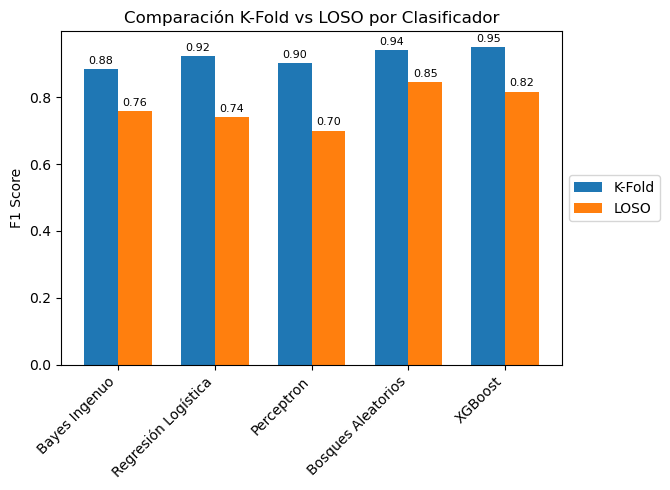

In [142]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1) Renombrar 'Perceptron' → 'MLP' en K-Fold
results_df_kfold = results_df_kfold.rename(index={'Perceptron': 'MLP'})

# 2) Renombrar columnas
kf = results_df_kfold.rename(columns={"F1 Score": "KFOLD F1 Score"})
loso = results_df_loso.rename(columns={"F1 Score": "LOSO F1 Score"})

# 3) Combinar y calcular Δ
results_comparison = pd.concat([kf, loso], axis=1)
results_comparison["Δ F1"] = results_comparison["LOSO F1 Score"] - results_comparison["KFOLD F1 Score"]

# 4) Reindexar en el orden deseado y renombrar a español
order_en = ["Naive Bayes", "Logistic Regression", "MLP", "Random Forest", "XGBoost"]
order_es = ["Bayes Ingenuo", "Regresión Logística", "Perceptron", "Bosques Aleatorios", "XGBoost"]

results_comparison = results_comparison.reindex(order_en)
results_comparison.index = order_es

# 5) Gráfico de barras agrupadas con puntajes encima
classifiers = results_comparison.index.tolist()
kf_scores   = results_comparison["KFOLD F1 Score"].values
loso_scores = results_comparison["LOSO F1 Score"].values

x = np.arange(len(classifiers))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
bars_kf = ax.bar(x - width/2, kf_scores,  width, label="K-Fold")
bars_loso = ax.bar(x + width/2, loso_scores, width, label="LOSO")

# Agregar etiquetas de puntaje encima de las barras
for bar in bars_kf:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.2f}", 
            ha='center', va='bottom', fontsize=8)

for bar in bars_loso:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.2f}", 
            ha='center', va='bottom', fontsize=8)

# Etiquetas y formato
ax.set_xticks(x)
ax.set_xticklabels(classifiers, rotation=45, ha='right')
ax.set_ylabel("F1 Score")
ax.set_title("Comparación K-Fold vs LOSO por Clasificador")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


Podemos analizar los sujetos para ver cuáles son los que están dando malos resultados. Podemos observar que lo smás problemáticos son el 2 y el 7. Esto indica que en general son más complicados de clasificar que los demás. Una de dos, puede ser underfitting u overfitting. 

GRÁFICA SOLO PARA FINES ILUSTRATIVOS. EL K-FOLD NO ES EL PROMEDIO DE CADA SUJETO SINO EL PROMEDIO DEL MODELO. 

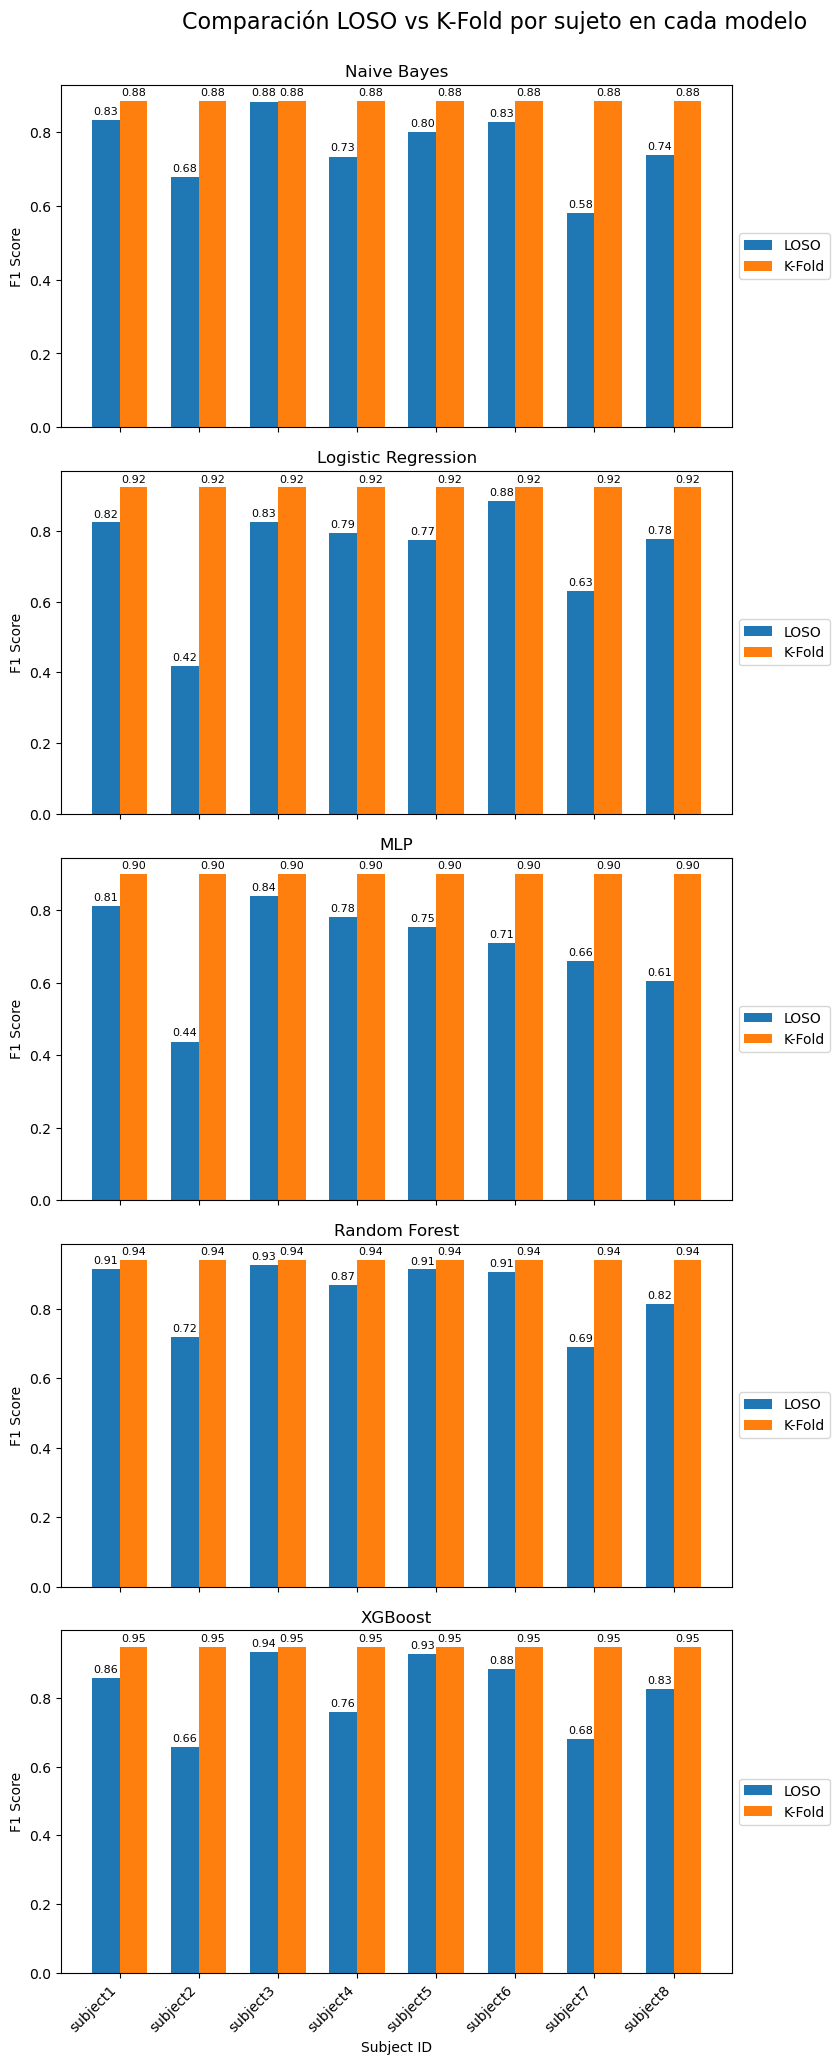

In [145]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Definir subjects
subjects = np.array([
    "subject1","subject2","subject3","subject4",
    "subject5","subject6","subject7","subject8"
])
n = len(subjects)

# 2) Diccionarios de resultados brutos
#    - nb_loso, lr_loso, etc. deben ser arrays de shape (n_subjects,) con cada corrida LOSO
#    - nb_results_kfold, lr_results_kfold, etc. deben ser arrays de shape (n_folds, n_subjects)
loso_dict = {
    "Naive Bayes":        nb_loso,
    "Logistic Regression": lr_loso,
    "MLP":                mlp_loso,
    "Random Forest":      rf_loso,
    "XGBoost":            xgb_loso
}
kfold_dict = {
    "Naive Bayes":        nb_results_kfold,
    "Logistic Regression": lr_results_kfold,
    "MLP":                percep_results_kfold,
    "Random Forest":      rf_results_kfold,
    "XGBoost":            xgb_results_kfold
}

# 3) Calcular promedios por sujeto
#    - LOSO: ya vienen por sujeto, pero si fuese varias corridas, harías np.mean(..., axis=0)
loso_mean_dict = { name: np.array(scores) for name, scores in loso_dict.items() }
#    - K-Fold: promediar sobre axis=0 (folds)
kfold_mean_dict = {
    name: np.mean(np.array(fold_scores), axis=0)
    for name, fold_scores in kfold_dict.items()
}

# 4) Crear figura con 5 subplots (uno por clasificador)
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(10, 20), sharex=True)

x = np.arange(n)
width = 0.35

for ax, name in zip(axes, loso_mean_dict.keys()):
    loso_scores = loso_mean_dict[name]
    kf_scores   = kfold_mean_dict[name]

    bars1 = ax.bar(x - width/2, loso_scores, width, label="LOSO")
    bars2 = ax.bar(x + width/2, kf_scores,   width, label="K-Fold")

    # Agregar texto arriba de cada barra
    for bar in bars1:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.2f}",
                ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.2f}",
                ha='center', va='bottom', fontsize=8)

    ax.set_ylabel('F1 Score')
    ax.set_title(name)
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.set_xticks(x)
    ax.set_xticklabels(subjects, rotation=45, ha='right')

# 5) Ajustar márgenes y mostrar
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.xlabel("Subject ID")
plt.suptitle("Comparación LOSO vs K-Fold por sujeto en cada modelo", y=1.02, fontsize=16)
plt.show()


Promediando los resulatdos de cada modelo tanto en kfold como en loso, podemos ver cómo varía en promedio (osea en general sin importar el clasificador) el desempeño de cada sujeto en K-Fold vs LOSO. Vemos que esto es constante en todos los clasificadores, no es que sea algo que un clasificador no funciona para esta tarea, es que todos tienen malos resultados para los sujetos 2 y 7 entre 0.5 y 0.7. 

# 12. Conclusión

Los resultados entre K-Fold y LOSO empeoran mucho. Los sujetos más afectados son el 2 y 7. Por otra parte, los clasificadores Regresión Logística y Perceptron.